In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import lightgbm as lgb
from google.colab import files

In [ ]:
file_path ='/content/fina_data_clean.csv'
data=pd.read_csv(file_path, delimiter=",", comment="#")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16632 entries, 0 to 16631
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pl_orbper    16632 non-null  float64
 1   pl_tranmid   16632 non-null  float64
 2   pl_trandep   16632 non-null  float64
 3   pl_trandur   16632 non-null  float64
 4   pl_rade      16632 non-null  float64
 5   pl_eqt       16632 non-null  float64
 6   pl_insol     16632 non-null  float64
 7   st_teff      16632 non-null  float64
 8   st_rad       16632 non-null  float64
 9   st_logg      16632 non-null  float64
 10  disposition  16632 non-null  float64
 11  pl_ratror    16632 non-null  float64
 12  st_mass      16632 non-null  float64
dtypes: float64(13)
memory usage: 1.6 MB


In [ ]:
data.describe()

,pl_orbper,pl_tranmid,pl_trandep,pl_trandur,pl_rade,pl_eqt,pl_insol,st_teff,st_rad,st_logg,disposition,pl_ratror,st_mass
count,16632.000000,1.663200e+04,1.663200e+04,16632.000000,16632.000000,16632.000000,1.663200e+04,16632.000000,16632.000000,16632.000000,16632.000000,16632.000000,16632.000000
mean,49.634686,1.099037e+06,1.659425e+04,24.193280,67.827102,1660.546647,5.149978e+03,5697.503113,1.524675,4.318520,-0.055135,3.438734,1.062832
std,1014.839584,1.222647e+06,6.253063e+04,150.154793,2291.583054,3265.794418,1.189000e+05,1136.836813,4.583354,0.382253,0.785000,5.798373,0.668361
min,0.163821,1.205159e+02,0.000000e+00,0.004208,0.080000,25.000000,0.000000e+00,2550.000000,0.109000,0.047000,-1.000000,0.000037,0.000000
25%,2.647370,1.356709e+02,2.971373e+02,0.134183,1.872120,650.000000,3.534000e+01,5251.750000,0.831000,4.176000,-1.000000,0.017999,0.846000
50%,5.866902,2.408475e+02,1.055600e+03,2.058000,4.440000,1028.000000,2.071695e+02,5763.000000,1.046000,4.410000,0.000000,0.239187,1.000000
75%,17.664065,2.459359e+06,7.054000e+03,4.586700,13.932826,1552.753345,9.642987e+02,6155.000000,1.487035,4.539000,1.000000,5.756792,1.158000
max,129995.778400,2.460863e+06,1.541400e+06,5451.338679,200346.000000,50399.798699,1.094755e+07,50000.000000,229.908000,5.960650,1.000000,99.870651,40.671489


In [ ]:
data.shape

(16632, 13)

### Data Visualization

In [ ]:
data.columns

Index(['pl_orbper', 'pl_tranmid', 'pl_trandep', 'pl_trandur', 'pl_rade',
       'pl_eqt', 'pl_insol', 'st_teff', 'st_rad', 'st_logg', 'disposition',
       'pl_ratror', 'st_mass'],
      dtype='object')

Number of samples falling in each category

array([[<Axes: title={'center': 'pl_orbper'}>,
        <Axes: title={'center': 'pl_tranmid'}>,
        <Axes: title={'center': 'pl_trandep'}>,
        <Axes: title={'center': 'pl_trandur'}>],
       [<Axes: title={'center': 'pl_rade'}>,
        <Axes: title={'center': 'pl_eqt'}>,
        <Axes: title={'center': 'pl_insol'}>,
        <Axes: title={'center': 'st_teff'}>],
       [<Axes: title={'center': 'st_rad'}>,
        <Axes: title={'center': 'st_logg'}>,
        <Axes: title={'center': 'disposition'}>,
        <Axes: title={'center': 'pl_ratror'}>],
       [<Axes: title={'center': 'st_mass'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

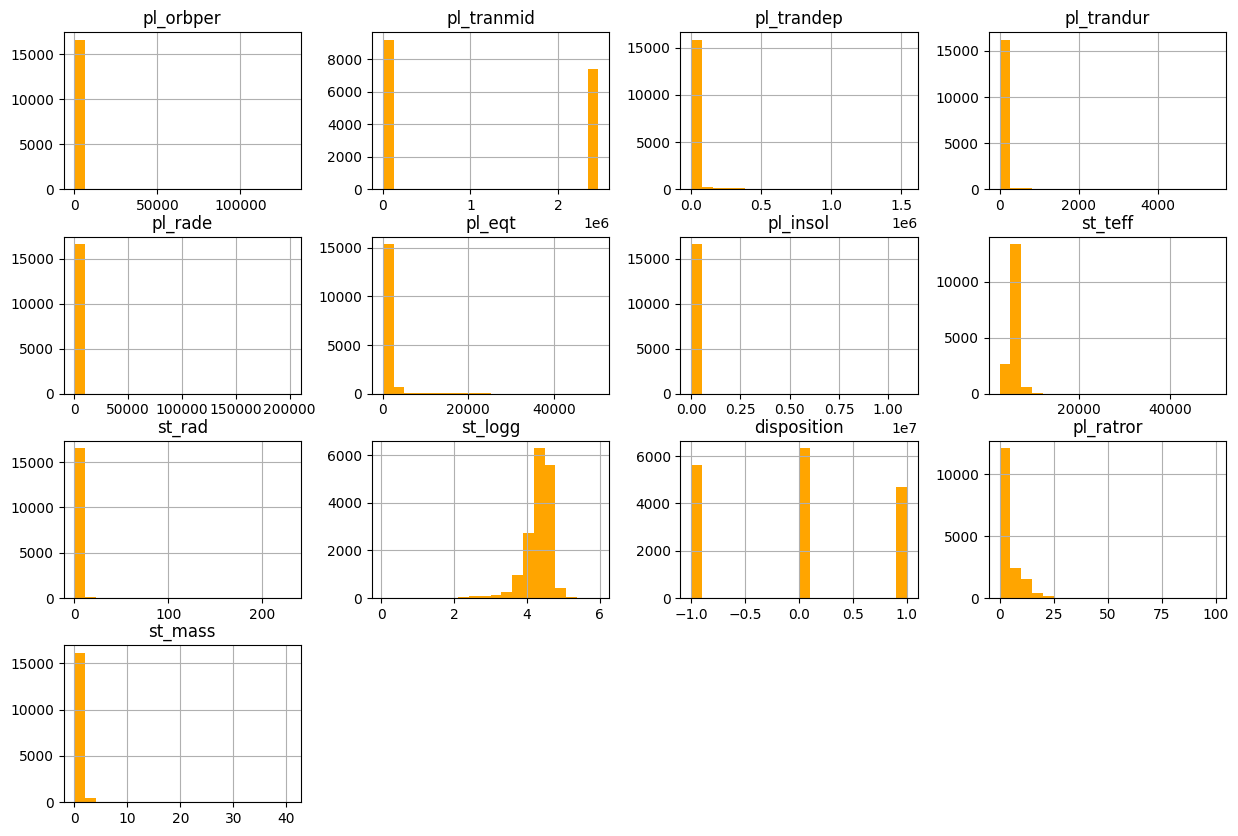

In [ ]:
data.hist(figsize=(15, 10), bins=20,color='orange')

**Correlation**

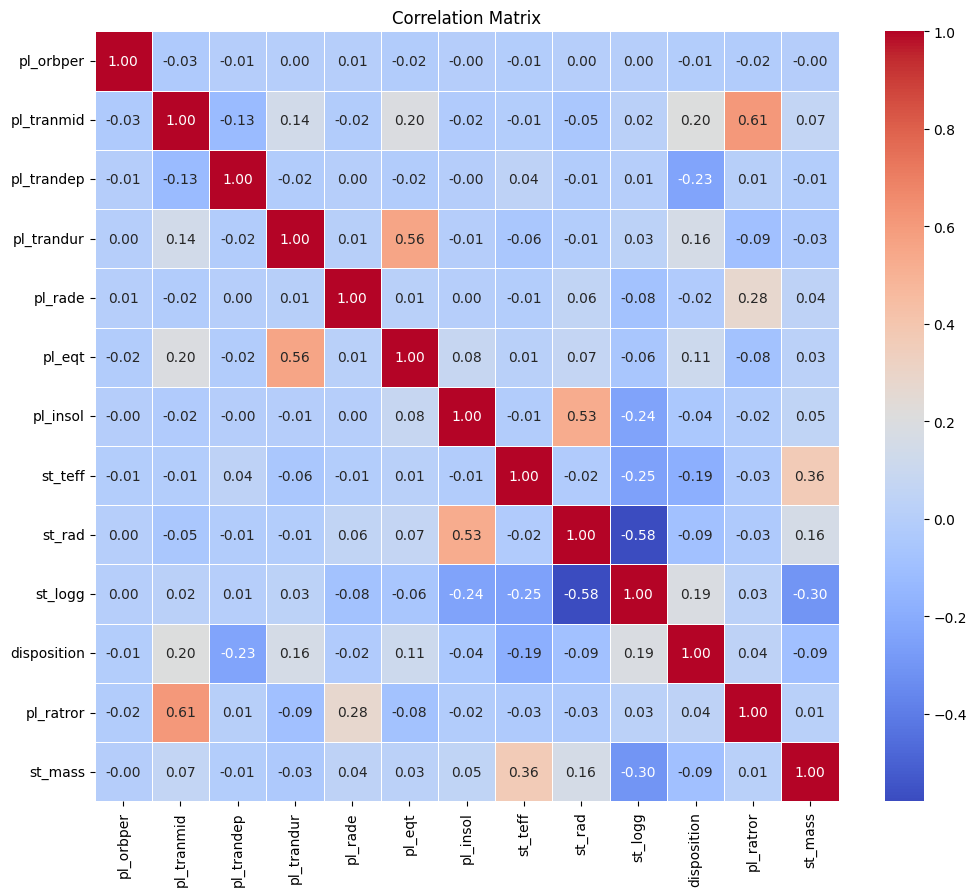

In [ ]:
corr_mat = data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
disposition_corr = corr_mat['disposition'].abs().sort_values(ascending=False)
print(disposition_corr)

disposition    1.000000
pl_trandep     0.234793
pl_tranmid     0.204791
st_teff        0.187938
st_logg        0.186385
pl_trandur     0.157019
pl_eqt         0.112189
st_mass        0.092884
st_rad         0.088123
pl_insol       0.043866
pl_ratror      0.043033
pl_rade        0.019656
pl_orbper      0.011391
Name: disposition, dtype: float64


 **Top 6 Effective Features**

pl_trandep: The size of the relative flux decrement caused by the orbiting body transiting in front of the star.

pl_tranmid: The time given by the average of the time the planet begins to cross the stellar limb and the time the planet finishes crossing the stellar limb.

st_teff: Stellar effective temperature value as reported in the TESS Input Catalog.

st_logg: Gravitational acceleration experienced at the stellar surface as reported in the TESS Input Catalog.

pl_trandur: The length of time from the moment the planet begins to cross the stellar limb to the moment the planet finishes crossing the stellar limb.

pl_eqt: The equilibrium temperature of the planet as modeled by a black body heated only by its host star.

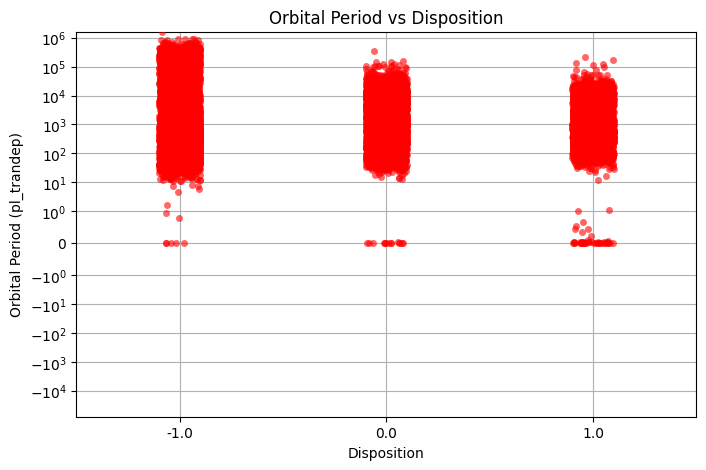

In [ ]:
plt.figure(figsize=(8, 5))
sns.stripplot(x='disposition', y='pl_trandep', data=data, jitter=True, alpha=0.6, color='red')
plt.title('Orbital Period vs Disposition')
plt.xlabel('Disposition')
plt.ylabel('Orbital Period (pl_trandep)')
plt.yscale('symlog', linthresh=1)
plt.grid(True)
plt.show()

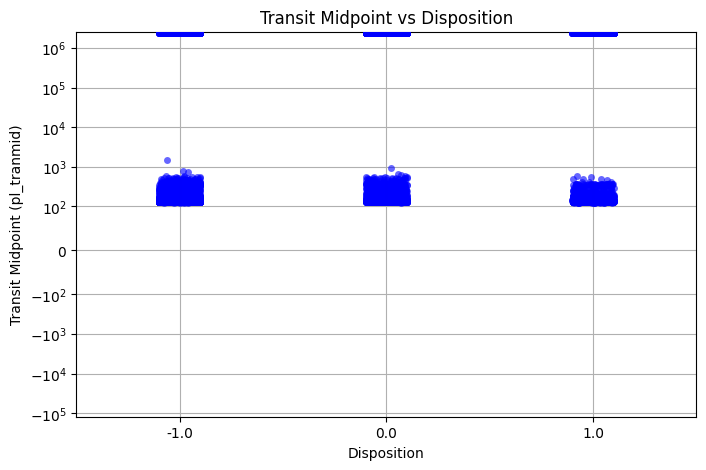

In [ ]:
plt.figure(figsize=(8, 5))
sns.stripplot(x='disposition', y='pl_tranmid', data=data, jitter=True, alpha=0.6, color='blue')
plt.title('Transit Midpoint vs Disposition')
plt.xlabel('Disposition')
plt.ylabel('Transit Midpoint (pl_tranmid)')
plt.yscale('symlog', linthresh=1e2)
plt.grid(True)
plt.show()

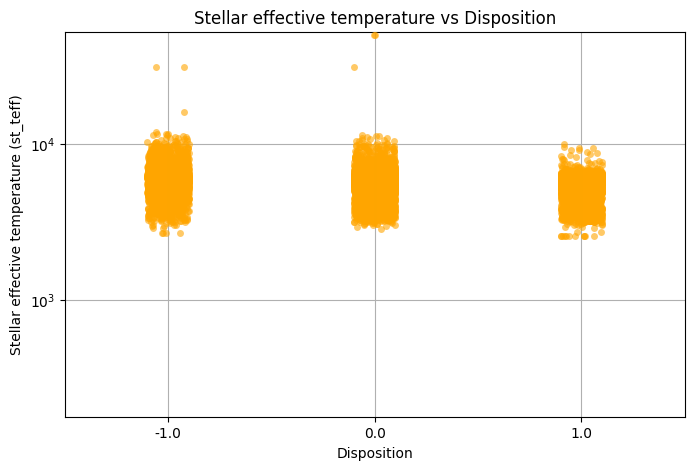

In [ ]:
plt.figure(figsize=(8, 5))
sns.stripplot(x='disposition', y='st_teff', data=data, jitter=True, alpha=0.6, color='orange')
plt.title('Stellar effective temperature vs Disposition')
plt.xlabel('Disposition')
plt.ylabel('Stellar effective temperature (st_teff)')
plt.yscale('symlog', linthresh=1e2)
plt.grid(True)
plt.show()

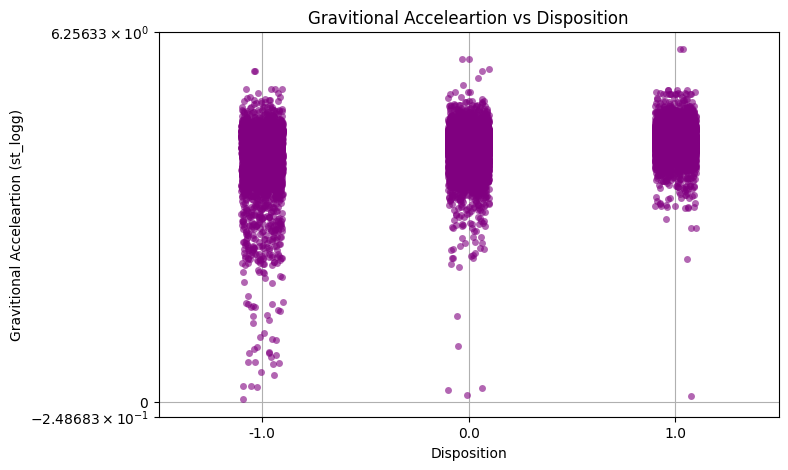

In [ ]:
plt.figure(figsize=(8, 5))
sns.stripplot(x='disposition', y='st_logg', data=data, jitter=True, alpha=0.6, color='Purple')
plt.title('Gravitional Acceleartion vs Disposition')
plt.xlabel('Disposition')
plt.ylabel('Gravitional Acceleartion (st_logg)')
plt.yscale('symlog', linthresh=1e2)
plt.grid(True)
plt.show()

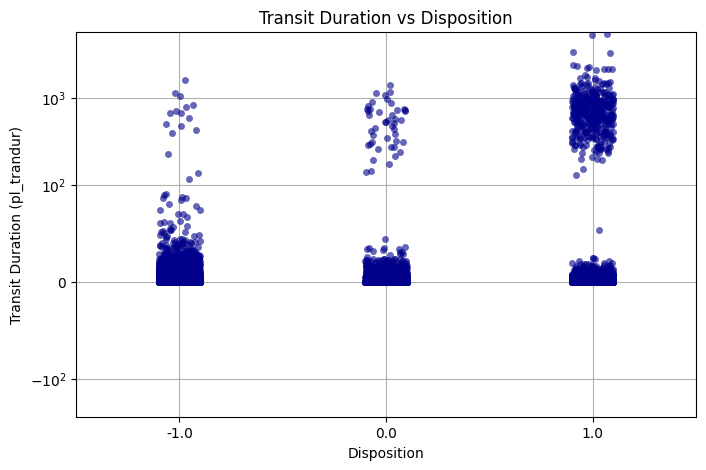

In [ ]:
plt.figure(figsize=(8, 5))
sns.stripplot(x='disposition', y='pl_trandur', data=data, jitter=True, alpha=0.6, color='darkblue')
plt.title('Transit Duration vs Disposition')
plt.xlabel('Disposition')
plt.ylabel('Transit Duration (pl_trandur)')
plt.yscale('symlog', linthresh=1e2)
plt.grid(True)
plt.show()

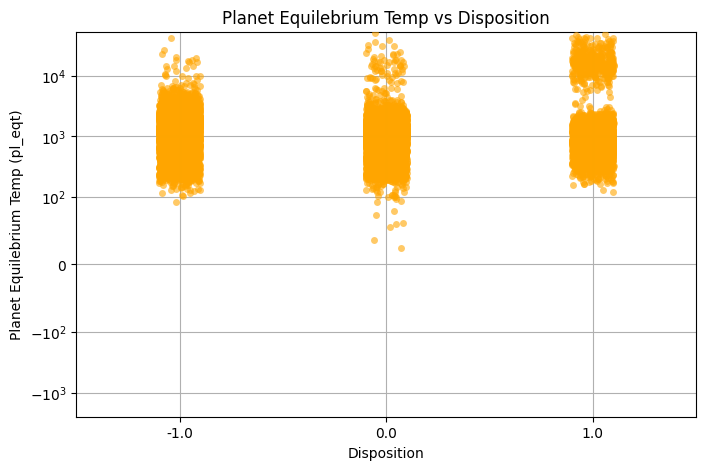

In [ ]:
plt.figure(figsize=(8, 5))
sns.stripplot(x='disposition', y='pl_eqt', data=data, jitter=True, alpha=0.6, color='Orange')
plt.title('Planet Equilebrium Temp vs Disposition')
plt.xlabel('Disposition')
plt.ylabel('Planet Equilebrium Temp (pl_eqt)')
plt.yscale('symlog', linthresh=1e2)
plt.grid(True)
plt.show()

### Model

In [ ]:
X = data.drop(columns=['disposition'])
y = data['disposition'].astype(int)

In [ ]:
X.columns = [str(col) for col in X.columns]

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
param_grid = {
    'n_estimators': [500, 1000, 1500, 2000],
    'learning_rate': [0.005, 0.01, 0.02, 0.05],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [6, 8, 10, -1],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.0, 0.1, 0.5, 1.0],
    'min_split_gain': [0.0, 0.1, 0.2],
    'boosting_type': ['gbdt', 'dart'],
}

In [ ]:
lgb_base = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(np.unique(y)),
    boosting_type='gbdt',
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='accuracy',
    cv=skf,
    verbose=1,
    random_state=42
)

In [ ]:
random_search.fit(X_train_full, y_train_full)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LGBMClassifier(class_weight='balanced', n_jobs=-1,
                                            num_class=3, objective='multiclass',
                                            random_state=42, verbose=-1),
                   n_iter=20,
                   param_distributions={'boosting_type': ['gbdt', 'dart'],
                                        'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.005, 0.01, 0.02,
                                                          0.05],
                                        'max_depth': [6, 8, 10, -1],
                                        'min_child_samples': [10, 20, 30, 50],
                                        'min_split_gain': [0.0, 0.1, 0.2],
                                        'n_estimators': [500, 1000, 1500, 2000],
                                        'num_leaves': [15, 31, 63, 127],
                                        'reg_alpha': [0.0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0.0, 0.1, 0.5, 1.0],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

In [ ]:
model_lgb = random_search.best_estimator_

In [ ]:
y_pred = model_lgb.predict(X_test)
print("\n=== Optimized LightGBM Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))



=== Optimized LightGBM Results ===
Accuracy: 0.7273820258491133
              precision    recall  f1-score   support

          -1       0.79      0.73      0.76      1122
           0       0.68      0.73      0.70      1267
           1       0.72      0.72      0.72       938

    accuracy                           0.73      3327
   macro avg       0.73      0.73      0.73      3327
weighted avg       0.73      0.73      0.73      3327

[[824 214  84]
 [174 919 174]
 [ 46 215 677]]
